In [8]:
# Compare with SMRT
import sys
sys.path.append('E:/exps/lunar_scattering/lunar_regolith_scattering/mores/python')
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as C

from VRT import VRT
# from MORES import MORES
# from init_tools import init_surface_from_mores, init_layer_from_mores
from postprocessing import Mueller2sigma0VH
from TransparentSurface import TransparentSurface
# from SmoothSurface import SmoothSurface

from AIEM import AIEM
from RayleighSphere import RayleighSphere
from RayleighSpherekskaeps import RayleighSpherekskaeps
from dieletric_models import diel_soil

In [9]:
freq = 13e9

epsr_bg = 1
# short alfalfa
d = 0.17
tau0 = 0.45
a = 0.27
# tall alfalfa
# d = 0.55
# tau0 = 2.5
# a = 0.175

ke = tau0 / d
ks = ke * a
ka = ke - ks
# subsurface
delta = 0.15e-2
corr_len = 1.5e-2
epsr2 = 15-4j
epsr2 = 80

c = C.speed_of_light
Lambda = c / freq
k = np.pi * 2 / Lambda
kdel = k * delta
kcor = k * corr_len


surface = TransparentSurface(epsilon_r=epsr_bg)
layer = RayleighSpherekskaeps(f=freq, epsr_background=epsr_bg, ks=ks, ka=ka, thickness=d)
subsurface = AIEM(epsilon_r=epsr2, kdel=kdel, kcor=kcor, corr_fun='exp')

vrt = VRT(surface, layer, subsurface)
# run model and plot
theta_is = np.linspace(1., 70., 70)
Num = len(theta_is)
sigma0_VVs = np.zeros(Num)
sigma0_HHs = np.zeros(Num)
sigma0_HVs = np.zeros(Num)
sig_tmp = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    theta_s = theta_i
    # Mue_surface = vrt.Mue_
    # Mue = vrt.Mue_volume_nosurface((theta_i, 180, theta_i, 0))
    Mue_sur = vrt.Mue_surface((theta_s, 180, theta_i, 0))
    Mue_vol = vrt.Mue_volume((theta_s, 180, theta_i, 0))
    Mue_sub = vrt.Mue_subsurface((theta_s, 180, theta_i, 0))
    Mue_sub_vol = vrt.Mue_subsurface_volume((theta_s, 180, theta_i, 0))
    Mue_total = Mue_sur + Mue_vol + Mue_sub + Mue_sub_vol
    # Mue = vrt.Mue_volume((theta_i, 180, theta_i, 0)) + vrt.Mue_surface((theta_i, 180, theta_i, 0))
    Mue = Mue_sub_vol
    sigma_VV, _, sigma_HV, sigma_HH = Mueller2sigma0VH(Mue)
    sigma0_VVs[i] = sigma_VV
    # sigma0_VVs[i] = 4*np.pi*Mue[0, 0]
    sigma0_HHs[i] = sigma_HH
    sigma0_HVs[i] = sigma_HV

    M = subsurface.Mue_noncoh_R((theta_i, 180, theta_i, 0))
    sig_tmp[i] = 10*np.log10(4*np.pi*M[0, 0])

sigma0_VV_dB = 10*np.log10(sigma0_VVs)
sigma0_HH_dB = 10*np.log10(sigma0_HHs)
# sigma0_HV_dB = 10*np.log10(sigma0_HVs)

C:\Users\zhaofei\AppData\Local\Temp\ipykernel_26704\1139254384.py:62: RuntimeWarning: divide by zero encountered in log10
  sigma0_VV_dB = 10*np.log10(sigma0_VVs)


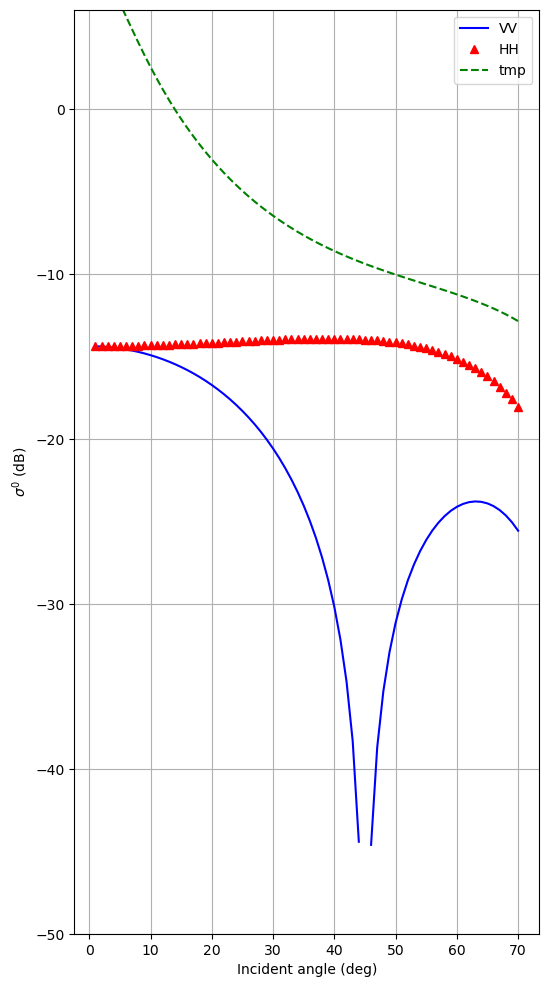

ks:0.7147058823529412, ka:1.9323529411764704, ke:2.6470588235294117, ssa:0.27


In [10]:
plt.figure(figsize=(6, 12))
plt.plot(theta_is, sigma0_VV_dB, 'b-', label='VV')
plt.plot(theta_is, sigma0_HH_dB, 'r^', label='HH')
plt.plot(theta_is, sig_tmp, 'g--', label='tmp')
plt.ylim(-50, 6)
# plt.yticks(np.arange(-20, 6, 1))
plt.xlabel('Incident angle (deg)')
plt.ylabel('$\sigma^0$ (dB)')
plt.legend()
plt.grid()
plt.show()
layer.print_params()